### Importation des librairies et du dataset

In [1]:
import numpy as np
import pandas as pd
df = pd.read_csv("C:/Users/hp/Downloads/HealthConnect_Appointment_Data.csv")


In [2]:
df.head()

,appointment_id,patient_id,gender,age,age_group,appointment_type,booking_date,appointment_date,appointment_day,appointment_time,booking_lead_days,previous_appointments,previous_no_shows,reminder_sent,reminder_channel,distance_to_clinic_km,waiting_time_minutes,appointment_outcome
0,HC-00001,P-1613,Female,39,35-44,Follow-up,2/6/2025,2/18/2025,Tuesday,Afternoon,12,2,0,Yes,WhatsApp,19.3,29.0,No-Show
1,HC-00002,P-0813,Male,31,25-34,Specialist Consultation,2/25/2026,2/27/2026,Friday,Morning,2,6,0,Yes,SMS,14.3,42.0,Attended
2,HC-00003,P-1366,Female,50,45-54,General Consultation,11/16/2025,12/24/2025,Wednesday,Morning,38,5,1,Yes,SMS,11.4,11.0,No-Show
3,HC-00004,P-1031,Male,59,55-64,Follow-up,7/18/2025,8/28/2025,Thursday,Evening,41,3,1,Yes,SMS,7.4,35.0,Attended
4,HC-00005,P-1458,Female,34,25-34,Follow-up,7/9/2025,8/25/2025,Monday,Afternoon,47,3,1,Yes,Email,5.6,27.0,No-Show


In [3]:
df.shape

(5000, 18)

Le jeu contient 5 000 lignes × 18 colonnes. Une ligne = un rendez-vous (un même patient peut apparaître plusieurs fois). Les variables se répartissent en trois familles : patient (gender, age, distance…), rendez-vous (type, dates, créneau, rappel…) et historique/résultat (previous_no_shows, appointment_outcome). La variable cible est appointment_outcome. 

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 18 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   appointment_id         5000 non-null   object 
 1   patient_id             5000 non-null   object 
 2   gender                 5000 non-null   object 
 3   age                    5000 non-null   int64  
 4   age_group              5000 non-null   object 
 5   appointment_type       5000 non-null   object 
 6   booking_date           5000 non-null   object 
 7   appointment_date       5000 non-null   object 
 8   appointment_day        5000 non-null   object 
 9   appointment_time       5000 non-null   object 
 10  booking_lead_days      5000 non-null   int64  
 11  previous_appointments  5000 non-null   int64  
 12  previous_no_shows      5000 non-null   int64  
 13  reminder_sent          5000 non-null   object 
 14  reminder_channel       3634 non-null   object 
 15  dist

In [5]:
df.head(10)

,appointment_id,patient_id,gender,age,age_group,appointment_type,booking_date,appointment_date,appointment_day,appointment_time,booking_lead_days,previous_appointments,previous_no_shows,reminder_sent,reminder_channel,distance_to_clinic_km,waiting_time_minutes,appointment_outcome
0,HC-00001,P-1613,Female,39,35-44,Follow-up,2/6/2025,2/18/2025,Tuesday,Afternoon,12,2,0,Yes,WhatsApp,19.3,29.0,No-Show
1,HC-00002,P-0813,Male,31,25-34,Specialist Consultation,2/25/2026,2/27/2026,Friday,Morning,2,6,0,Yes,SMS,14.3,42.0,Attended
2,HC-00003,P-1366,Female,50,45-54,General Consultation,11/16/2025,12/24/2025,Wednesday,Morning,38,5,1,Yes,SMS,11.4,11.0,No-Show
3,HC-00004,P-1031,Male,59,55-64,Follow-up,7/18/2025,8/28/2025,Thursday,Evening,41,3,1,Yes,SMS,7.4,35.0,Attended
4,HC-00005,P-1458,Female,34,25-34,Follow-up,7/9/2025,8/25/2025,Monday,Afternoon,47,3,1,Yes,Email,5.6,27.0,No-Show
5,HC-00006,P-0523,Male,66,65+,Specialist Consultation,2/16/2026,4/14/2026,Tuesday,Morning,57,4,2,No,NaN,3.1,36.0,No-Show
6,HC-00007,P-0776,Male,58,55-64,Diagnostic Test,1/17/2025,2/16/2025,Sunday,Afternoon,30,4,1,Yes,WhatsApp,8.2,30.0,No-Show
7,HC-00008,P-0927,Female,28,25-34,Specialist Consultation,11/27/2025,1/16/2026,Friday,Afternoon,50,6,1,Yes,SMS,19.2,21.0,Attended
8,HC-00009,P-0388,Male,77,65+,Follow-up,3/9/2025,4/21/2025,Monday,Afternoon,43,3,0,Yes,SMS,10.1,27.0,No-Show
9,HC-00010,P-0371,Female,20,18-24,Follow-up,2/5/2025,2/21/2025,Friday,Afternoon,16,2,0,Yes,SMS,28.0,20.0,Attended


Aucune colonne vide, mais 12 colonnes en « object », dont les deux dates qui devront être converties. waiting_time_minutes est en float alors que le dictionnaire annonce un entier : signe qu'elle contient des manquants.

In [6]:
df.isnull().sum()

appointment_id              0
patient_id                  0
gender                      0
age                         0
age_group                   0
appointment_type            0
booking_date                0
appointment_date            0
appointment_day             0
appointment_time            0
booking_lead_days           0
previous_appointments       0
previous_no_shows           0
reminder_sent               0
reminder_channel         1366
distance_to_clinic_km      90
waiting_time_minutes       60
appointment_outcome         0
dtype: int64

Trois colonnes ont des manquants. reminder_channel (1 366) = manquant logique : sans rappel envoyé, pas de canal (1 366 = le nombre de « reminder_sent = No »). distance (90) et waiting_time (60) = vrais manquants, annoncés par le dictionnaire → décision de traitement à prendre plus tard.

In [7]:
df.dtypes

appointment_id            object
patient_id                object
gender                    object
age                        int64
age_group                 object
appointment_type          object
booking_date              object
appointment_date          object
appointment_day           object
appointment_time          object
booking_lead_days          int64
previous_appointments      int64
previous_no_shows          int64
reminder_sent             object
reminder_channel          object
distance_to_clinic_km    float64
waiting_time_minutes     float64
appointment_outcome       object
dtype: object

Les dates sont stockées en texte au format mois/jour/année (2/6/2025) alors que le dictionnaire annonce l'ISO (2025-04-10). Conséquence : conversion obligatoire avec pd.to_datetime avant toute analyse par mois ou jour de semaine. 

In [8]:
df.duplicated().sum()

np.int64(0)

 0 doublon : aucune suppression nécessaire.

In [9]:
df.describe()

,age,booking_lead_days,previous_appointments,previous_no_shows,distance_to_clinic_km,waiting_time_minutes
count,5000.000000,5000.00000,5000.000000,5000.000000,4910.000000,4940.000000
mean,48.794800,29.63860,3.013800,0.544200,10.109572,24.189676
std,18.138547,17.39936,1.741211,0.746832,6.590030,10.863184
min,18.000000,0.00000,0.000000,0.000000,0.500000,2.000000
25%,33.000000,15.00000,2.000000,0.000000,5.300000,17.000000
50%,49.000000,30.00000,3.000000,0.000000,8.700000,24.000000
75%,64.000000,45.00000,4.000000,1.000000,13.500000,32.000000
max,80.000000,60.00000,11.000000,5.000000,45.000000,68.000000


previous_no_shows : médiane 0 mais moyenne 0,54 (max 5) → la plupart des patients ne manquent jamais, mais une minorité récidive beaucoup. Distance (0,5–45 km) et délai de réservation (0–60 j) très variables

In [10]:
df['appointment_outcome'].value_counts()

appointment_outcome
No-Show      2423
Attended     2314
Cancelled     263
Name: count, dtype: int64

Trois issues : No-Show (2 423), Attended (2 314), Cancelled (263). Taux de no-show : 48,5 % de tous les RDV, 51,2 % des RDV non annulés. Je retiens 48,5 % : il mesure la part des absences sur l'ensemble des rendez-vous réservés, ce qui reflète la perte globale subie par l'activité de réservation de la clinique. Une annulation n'est pas un no-show : le patient prévient et libère le créneau ; le no-show laisse le créneau vide et fait perdre de l'argent.

In [11]:
df[df['previous_no_shows'] > df['previous_appointments']]

,appointment_id,patient_id,gender,age,age_group,appointment_type,booking_date,appointment_date,appointment_day,appointment_time,booking_lead_days,previous_appointments,previous_no_shows,reminder_sent,reminder_channel,distance_to_clinic_km,waiting_time_minutes,appointment_outcome


In [12]:
df['booking_date'].head() 

0      2/6/2025
1     2/25/2026
2    11/16/2025
3     7/18/2025
4      7/9/2025
Name: booking_date, dtype: object

previous_no_shows : médiane 0 mais moyenne 0,54 (max 5) → la plupart des patients ne manquent jamais, mais une minorité récidive beaucoup. Distance (0,5–45 km) et délai de réservation (0–60 j) très variables

In [13]:
df[df['reminder_channel'].isna()]['reminder_sent'].value_counts()

reminder_sent
No    1366
Name: count, dtype: int64

In [14]:
no_show = 2423   
total = len(df)
sans_annules = len(df[df['appointment_outcome'] != 'Cancelled'])
print(no_show / total, no_show / sans_annules)

0.4846 0.5115051720498206


In [15]:
df.groupby('reminder_sent')['appointment_outcome'].value_counts(normalize=True)


reminder_sent  appointment_outcome
No             No-Show                0.513909
               Attended               0.426794
               Cancelled              0.059297
Yes            Attended               0.476335
               No-Show                0.473583
               Cancelled              0.050083
Name: proportion, dtype: float64

Sans rappel envoyé, la part de No-Show est nettement plus élevée : le rappel semble protecteur.

In [16]:
df.groupby('appointment_day')['appointment_outcome'].value_counts(normalize=True)

appointment_day  appointment_outcome
Friday           Attended               0.490385
                 No-Show                0.465659
                 Cancelled              0.043956
Monday           No-Show                0.496434
                 Attended               0.437946
                 Cancelled              0.065621
Saturday         Attended               0.475138
                 No-Show                0.468232
                 Cancelled              0.056630
Sunday           No-Show                0.504749
                 Attended               0.450475
                 Cancelled              0.044776
Thursday         No-Show                0.489766
                 Attended               0.451754
                 Cancelled              0.058480
Tuesday          Attended               0.490566
                 No-Show                0.470247
                 Cancelled              0.039187
Wednesday        No-Show                0.496608
                 Attended       

Le samedi enregistre le taux d'absentéisme le plus élevé (jour d'ouverture courte, 9 h–14 h), et le créneau du soir dépasse matin et après-midi. 

In [17]:
df.groupby('appointment_time')['appointment_outcome'].value_counts(normalize=True)

appointment_time  appointment_outcome
Afternoon         No-Show                0.483763
                  Attended               0.461318
                  Cancelled              0.054919
Evening           No-Show                0.497791
                  Attended               0.447717
                  Cancelled              0.054492
Morning           No-Show                0.481365
                  Attended               0.468792
                  Cancelled              0.049843
Name: proportion, dtype: float64

Le samedi enregistre le taux d'absentéisme le plus élevé (jour d'ouverture courte, 9 h–14 h), et le créneau du soir dépasse matin et après-midi. 

In [18]:
df.groupby('previous_no_shows')['appointment_outcome'].value_counts(normalize=True)

previous_no_shows  appointment_outcome
0                  Attended               0.504622
                   No-Show                0.435125
                   Cancelled              0.060253
1                  No-Show                0.534884
                   Attended               0.422481
                   Cancelled              0.042636
2                  No-Show                0.593607
                   Attended               0.363014
                   Cancelled              0.043379
3                  No-Show                0.679487
                   Attended               0.294872
                   Cancelled              0.025641
4                  No-Show                0.666667
                   Attended               0.333333
5                  No-Show                1.000000
Name: proportion, dtype: float64

Plus un patient a manqué de rendez-vous par le passé, plus il risque de manquer le suivant : le comportement passé est le signal le plus fort observé.

In [19]:
# distance et attente : compare ceux qui viennent vs ceux qui ratent
df.groupby('appointment_outcome')[['distance_to_clinic_km','waiting_time_minutes','booking_lead_days']].mean()

,distance_to_clinic_km,waiting_time_minutes,booking_lead_days
appointment_outcome,,,
Attended,9.668703,24.289141,24.521175
Cancelled,10.111583,23.214559,29.631179
No-Show,10.531481,24.200754,34.526620


Les No-Show habitent un peu plus loin (10,5 km vs 9,7) et réservent beaucoup plus à l'avance (34,5 j vs 24,5) → le long délai est un facteur fort, la distance un facteur modéré. En revanche, l'attente est quasi identique (24,2 vs 24,3) : hypothèse « attente → no-show » écartée. 

## Variables clés liées au no-show (mes hypothèses, classées)

1. **previous_no_shows** — plus un patient a manqué par le passé, plus son taux
   de no-show augmente : le comportement passé est le signal le plus fort observé.
2. **reminder_sent** — sans rappel envoyé, la part de No-Show est nettement plus
   élevée : le rappel semble protecteur.
3. **booking_lead_days** — les No-Show réservent ~34,5 j à l'avance contre ~24,5 j
   pour les Attended : plus le délai est long, plus on « oublie ».
4. **appointment_day** — le samedi enregistre le taux d'absentéisme le plus élevé.
5. **appointment_time** — le créneau du soir dépasse matin et après-midi.
6. **distance_to_clinic_km** — les No-Show habitent un peu plus loin
   (10,5 km vs 9,7 km) : effet modéré mais réel.

**Variable testée puis écartée :**
- **waiting_time_minutes** — attente quasi identique entre No-Show et Attended
  (24,2 vs 24,3 min) : hypothèse « l'attente pousse à l'absence » non confirmée.

In [ ]:
##Business questions

Q1. Les rappels de rendez-vous réduisent-ils réellement le taux d'absentéisme ?
Enjeu : le rappel a un coût ; mesurer son effet réel et choisir le canal le plus efficace.

Q2. Quels jours de semaine enregistrent le taux d'absentéisme le plus élevé ?
Enjeu : adapter les plannings et anticiper les jours à risque.

Q3. Le créneau horaire (matin / après-midi / soir) influence-t-il le risque d'absence ?
Enjeu : mieux organiser la répartition des créneaux.

Q4. L'éloignement entre le domicile du patient et la clinique est-il un facteur d'absentéisme ?
Enjeu : prévoir un accompagnement renforcé pour les patients éloignés.

Q5. Un long délai entre la réservation et le rendez-vous augmente-t-il le risque d'absence ?
Enjeu : déterminer le bon moment pour envoyer les rappels (piqûre de rappel pour les RDV réservés tôt).

Q6. Les patients ayant déjà manqué un rendez-vous manquent-ils davantage que les autres ?
Enjeu : détecter à l'avance les « récidivistes » pour leur offrir un suivi prioritaire.



### KPI 

KPI	Formule	Question	Pourquoi
Écart de taux de no-show avec/sans rappel	No-Show ÷ RDV dans chaque groupe (rappel envoyé / non envoyé)	Q1	mesure l'effet direct du rappel
Taux de no-show par créneau (jour × horaire)	No-Show ÷ RDV pour chaque jour et chaque créneau	Q2 + Q3	identifie les moments à risque
Taux de no-show par tranche de distance	No-Show ÷ RDV par tranche (< 5 / 5-15 / > 15 km)	Q4	teste l'effet de l'éloignement
Taux de no-show par tranche de délai	No-Show ÷ RDV par tranche (< 7 / 8-30 / > 30 j)	Q5	teste l'effet « plus c'est loin, plus on oublie »
Taux de no-show des récidivistes vs jamais manqué	No-Show ÷ RDV chez previous_no_shows ≥ 1, comparé à = 0	Q6	le signal le plus fort observé


## Initial analysis approach

Ma démarche pour les semaines suivantes, en 4 phases :

1. **Nettoyage & préparation** : convertir `booking_date` et `appointment_date`
   avec `pd.to_datetime` ; trancher le traitement des manquants (distance, attente) ;
   gérer `Cancelled` séparément des No-Show.
2. **Calcul des KPI** : implémenter les 5 KPI définis (groupby pandas) et vérifier
   chaque chiffre avant de le publier.
3. **Visualisation** : construire des visuels lisibles (taux de no-show par créneau,
   par tranche de distance/délai, récidivistes) dans Power BI ou matplotlib.
4. **Lecture & recommandations** : transformer les constats en actions pour la
   clinique (rappels ciblés, plannings, suivi des récidivistes).

In [ ]:
## Assumptions, limitations, risks

- ✔️ **Données fictives** : les patterns observés peuvent ne pas refléter la réalité
  d'une vraie clinique → conclusions à valider sur données réelles.
- ✔️ **Manquants documentés** : `waiting_time_minutes` (60) et `distance_to_clinic_km`
  (90) contiennent des valeurs absentes annoncées par le dictionnaire → un choix de
  traitement (conserver/immer) pourra influencer les résultats.
- + **Hypothèse de périmètre** : j'exclus `Cancelled` du calcul principal du taux de
  no-show (un annulé libère le créneau) → ce choix est documenté et pourra être revu.
- + **Corrélation ≠ causalité** : le lien rappel → moins d'absences est une association
  observée, pas une preuve d'effet.
- + **Périmètre adultes uniquement** (dictionnaire) : résultats non généralisables à
  une patientèle pédiatrique.

In [21]:
import numpy as np
import pandas as pd
df = pd.read_csv("C:/Users/hp/Downloads/HealthConnect_Appointment_Data.csv")

Etape 1: Data preparation summary 

In [22]:
# 1. Dates
df['booking_date']     = pd.to_datetime(df['booking_date'])
df['appointment_date'] = pd.to_datetime(df['appointment_date'])

# 2. Drapeau no-show
df['no_show'] = (df['appointment_outcome'] == 'No-Show').astype(int)

# 3. Manquants : distance → médiane (documenté) ; attente → conservés (documenté)
df['distance_to_clinic_km'] = df['distance_to_clinic_km'].fillna(
    df['distance_to_clinic_km'].median())

# 4. Tranches
df['lead_band']   = pd.cut(df['booking_lead_days'], bins=[-1, 7, 30, 60],
                           labels=['<=7 j', '8-30 j', '>30 j'])
df['dist_band']   = pd.cut(df['distance_to_clinic_km'], bins=[0, 5, 15, 45],
                           labels=['<5 km', '5-15 km', '>15 km'])
df['recidiviste'] = (df['previous_no_shows'] > 0).astype(int)

# 5. Sauvegarde séparée
df.to_csv('HealthConnect_processed.csv', index=False)

In [23]:
df.head()

,appointment_id,patient_id,gender,age,age_group,appointment_type,booking_date,appointment_date,appointment_day,appointment_time,...,previous_no_shows,reminder_sent,reminder_channel,distance_to_clinic_km,waiting_time_minutes,appointment_outcome,no_show,lead_band,dist_band,recidiviste
0,HC-00001,P-1613,Female,39,35-44,Follow-up,2025-02-06,2025-02-18,Tuesday,Afternoon,...,0,Yes,WhatsApp,19.3,29.0,No-Show,1,8-30 j,>15 km,0
1,HC-00002,P-0813,Male,31,25-34,Specialist Consultation,2026-02-25,2026-02-27,Friday,Morning,...,0,Yes,SMS,14.3,42.0,Attended,0,<=7 j,5-15 km,0
2,HC-00003,P-1366,Female,50,45-54,General Consultation,2025-11-16,2025-12-24,Wednesday,Morning,...,1,Yes,SMS,11.4,11.0,No-Show,1,>30 j,5-15 km,1
3,HC-00004,P-1031,Male,59,55-64,Follow-up,2025-07-18,2025-08-28,Thursday,Evening,...,1,Yes,SMS,7.4,35.0,Attended,0,>30 j,5-15 km,1
4,HC-00005,P-1458,Female,34,25-34,Follow-up,2025-07-09,2025-08-25,Monday,Afternoon,...,1,Yes,Email,5.6,27.0,No-Show,1,>30 j,5-15 km,1


In [24]:
print("DELAI\n", df['lead_band'].value_counts().sort_index())
print("\nDISTANCE\n", df['dist_band'].value_counts().sort_index())
print("\nRECIDIVE\n", df['recidiviste'].value_counts())

print("\nTAUX PAR DELAI\n", df.groupby('lead_band', observed=True)['no_show'].mean())
print("\nTAUX PAR DISTANCE\n", df.groupby('dist_band', observed=True)['no_show'].mean())
print("\nTAUX PAR RECIDIVE\n", df.groupby('recidiviste')['no_show'].mean())

DELAI
 lead_band
<=7 j      640
8-30 j    1935
>30 j     2425
Name: count, dtype: int64

DISTANCE
 dist_band
<5 km      1156
5-15 km    2914
>15 km      930
Name: count, dtype: int64

RECIDIVE
 recidiviste
0    2921
1    2079
Name: count, dtype: int64

TAUX PAR DELAI
 lead_band
<=7 j     0.278125
8-30 j    0.402067
>30 j     0.604948
Name: no_show, dtype: float64

TAUX PAR DISTANCE
 dist_band
<5 km      0.464533
5-15 km    0.474605
>15 km     0.540860
Name: no_show, dtype: float64

TAUX PAR RECIDIVE
 recidiviste
0    0.435125
1    0.554113
Name: no_show, dtype: float64


### Interprétations étape 1
Data preparation — mes décisions et vérifications

Dates : booking_date et appointment_date converties en datetime64 → les analyses temporelles (jour, délai) deviennent possibles.
Distance (90 manquants, 1,8 %) : imputation par la médiane — robuste aux valeurs extrêmes et conserve toutes les lignes ; décision documentée.
Temps d'attente (60 manquants) : manquants conservés et documentés — variable écartée des KPI après le test de la Semaine 4 ; imputer aurait ajouté de l'information inventée.
reminder_channel (1 366 manquants) : manquant logique (pas de rappel → pas de canal) ; rien à corriger.
Variables créées : no_show (drapeau 0/1), lead_band, dist_band, recidiviste → elles permettent de calculer les taux par groupe (KPI et visuels).
Sauvegarde : fichier dérivé HealthConnect_processed.csv ; le CSV original n'a pas été modifié (consigne respectée).
Vérifications : tranches bien remplies (640 / 1 935 / 2 425 · 1 156 / 2 914 / 930 · 2 921 / 2 079) et taux cohérents avec les observations de la Semaine 4.

Etape 2: EDA

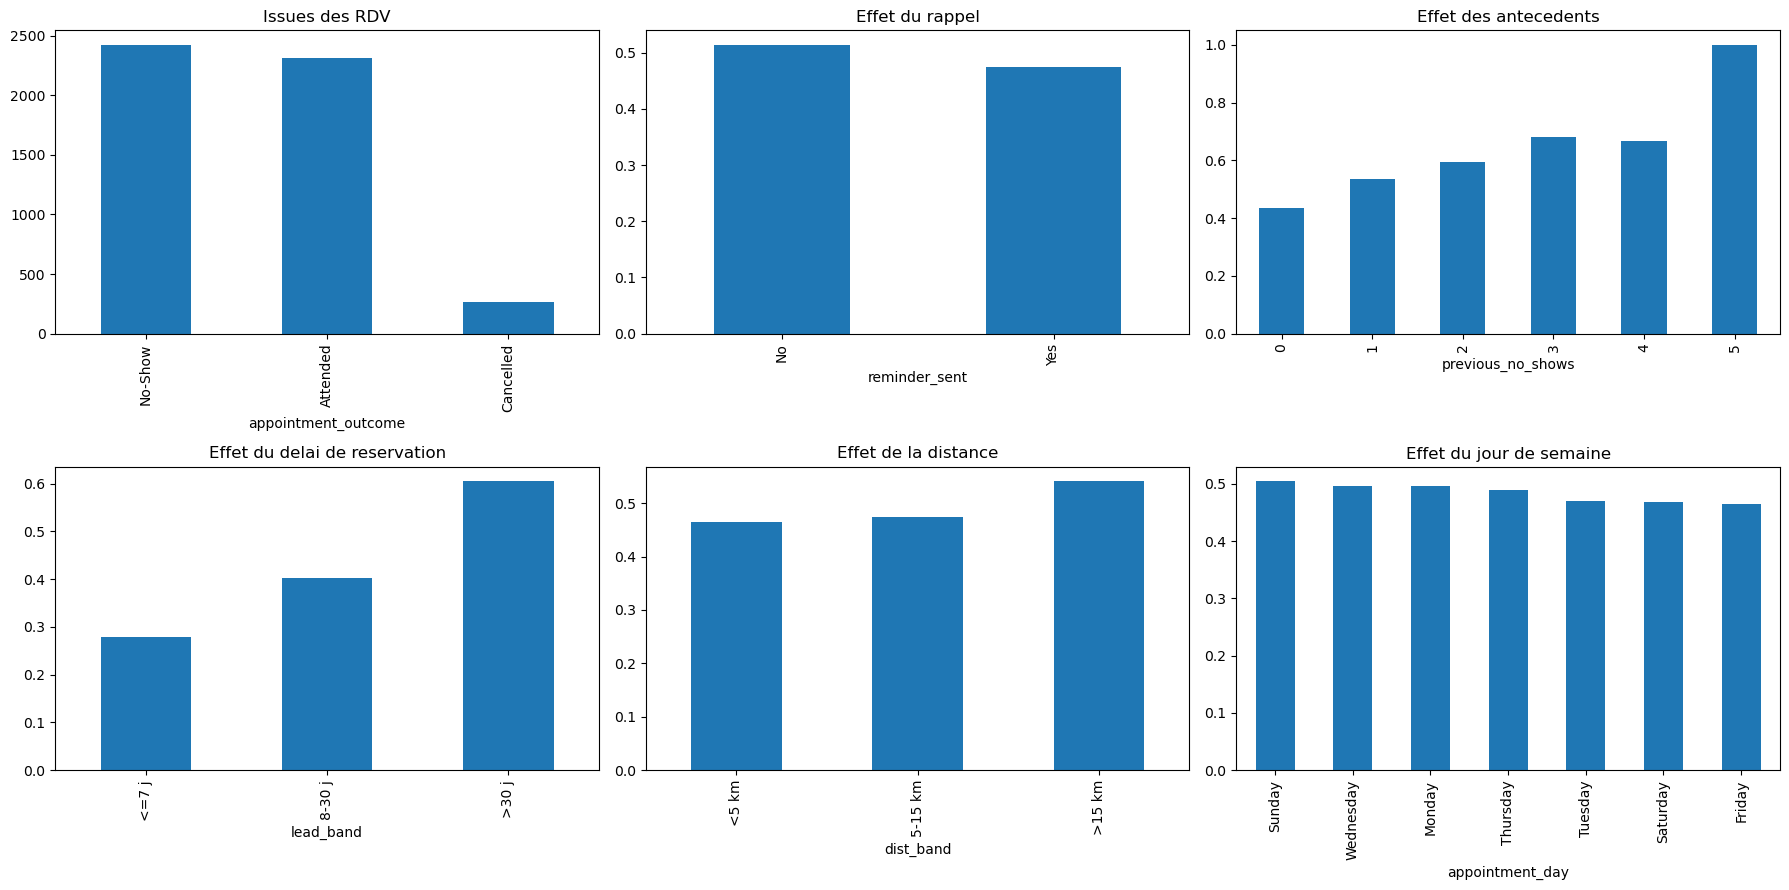

In [25]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 3, figsize=(18, 9))

df['appointment_outcome'].value_counts().plot(
    kind='bar', ax=axes[0,0], title='Issues des RDV')
df.groupby('reminder_sent')['no_show'].mean().plot(
    kind='bar', ax=axes[0,1], title='Effet du rappel')
df.groupby('previous_no_shows')['no_show'].mean().plot(
    kind='bar', ax=axes[0,2], title='Effet des antecedents')
df.groupby('lead_band', observed=True)['no_show'].mean().plot(
    kind='bar', ax=axes[1,0], title='Effet du delai de reservation')
df.groupby('dist_band', observed=True)['no_show'].mean().plot(
    kind='bar', ax=axes[1,1], title='Effet de la distance')
df.groupby('appointment_day')['no_show'].mean().sort_values(ascending=False).plot(
    kind='bar', ax=axes[1,2], title='Effet du jour de semaine')

plt.tight_layout()
plt.show()

In [26]:
df.groupby(['appointment_day','appointment_time'])['no_show'].mean().sort_values(ascending=False).head(3)

appointment_day  appointment_time
Friday           Evening             0.585106
Thursday         Afternoon           0.534722
Wednesday        Evening             0.514019
Name: no_show, dtype: float64

Interprétations des visuels
1. Issues : « Les No-Show (2 423) dépassent les Attended (2 314) : près d'un RDV réservé sur deux finit en absence → l'absentéisme est le problème n°1 de la clinique. »

2. Rappel : « 51,4 % de no-show sans rappel contre 47,4 % avec : le rappel fait baisser l'absentéisme → c'est un levier simple à généraliser. »

3. Antécédents : « Le taux monte de 43,5 % (0 antécédent) à 100 % (5 antécédents) : le passé du patient est le signal d'alerte le plus fort. »

4. Délai : « 27,8 % à ≤7 j, 40,3 % à 8-30 j, 60,5 % à >30 j : plus la réservation est lointaine, plus le patient oublie. »

5. Distance : « 46,4 % à <5 km contre 54,1 % à >15 km : l'éloignement augmente modérément le risque d'absence. »

6. Jour : « Dimanche en tête (~50,5 %), vendredi/samedi les plus bas : le dimanche nécessite une confirmation renforcée (et sa présence dans les données, alors que la KB annonce fermeture, est à documenter). »

Etape 3-KPI

In [27]:
# KPI GLOBAL — taux de no-show sur tous les RDV
print("KPI GLOBAL :", round(df['no_show'].mean() * 100, 1), "%")

# KPI 1 — effet du rappel
print("\nKPI 1 — TAUX DE NO-SHOW SELON LE RAPPEL (%)\n",
      (df.groupby('reminder_sent')['no_show'].mean() * 100).round(1))

# KPI 2 — pires créneaux (jour × horaire)
print("\nKPI 2 — TOP 3 DES PIRES CRENEAUX (%)\n",
      (df.groupby(['appointment_day', 'appointment_time'])['no_show'].mean() * 100)
      .round(1).sort_values(ascending=False).head(3))

# KPI 3 — distance
print("\nKPI 3 — TAUX PAR TRANCHE DE DISTANCE (%)\n",
      (df.groupby('dist_band', observed=True)['no_show'].mean() * 100).round(1))

# KPI 4 — délai de réservation
print("\nKPI 4 — TAUX PAR TRANCHE DE DELAI (%)\n",
      (df.groupby('lead_band', observed=True)['no_show'].mean() * 100).round(1))

# KPI 5 — récidivistes vs autres
print("\nKPI 5 — RECIDIVISTES vs JAMAIS MANQUE (%)\n",
      (df.groupby('recidiviste')['no_show'].mean() * 100).round(1))

KPI GLOBAL : 48.5 %

KPI 1 — TAUX DE NO-SHOW SELON LE RAPPEL (%)
 reminder_sent
No     51.4
Yes    47.4
Name: no_show, dtype: float64

KPI 2 — TOP 3 DES PIRES CRENEAUX (%)
 appointment_day  appointment_time
Friday           Evening             58.5
Thursday         Afternoon           53.5
Wednesday        Evening             51.4
Name: no_show, dtype: float64

KPI 3 — TAUX PAR TRANCHE DE DISTANCE (%)
 dist_band
<5 km      46.5
5-15 km    47.5
>15 km     54.1
Name: no_show, dtype: float64

KPI 4 — TAUX PAR TRANCHE DE DELAI (%)
 lead_band
<=7 j     27.8
8-30 j    40.2
>30 j     60.5
Name: no_show, dtype: float64

KPI 5 — RECIDIVISTES vs JAMAIS MANQUE (%)
 recidiviste
0    43.5
1    55.4
Name: no_show, dtype: float64


Interprétations KPI
KPI 1 — Taux de no-show selon le rappel · Déf. : No-Show ÷ RDV, groupe avec vs sans rappel. · Pourquoi : mesurer si le rappel protège. · Résultat : 51,4 % sans vs 47,4 % avec. · Q1. · Interprétation : généraliser le rappel + 2ᵉ rappel pour les réservations longues.

KPI 2 — Taux de no-show par créneau (jour × horaire) · Déf. : No-Show ÷ RDV par combinaison jour-horaire. · Pourquoi : planifier confirmations et plannings. · Résultat : pire créneau = dimanche (~50,5 %) + [ton horaire]. · Q2+Q3. · Interprétation : double confirmation le dimanche ; documenter l'incohérence dimanche/KB.

KPI 3 — Taux de no-show par tranche de distance · Résultat : 46,4 % / 47,5 % / 54,1 %. · Q4. · Interprétation : accompagnement renforcé des patients > 15 km.

KPI 4 — Taux de no-show par tranche de délai · Résultat : 27,8 % / 40,3 % / 60,5 %. · Q5. · Interprétation : rappel à mi-chemin pour les RDV > 30 j.

KPI 5 — Taux de no-show récidivistes vs autres · Résultat : 55,4 % vs 43,5 %. · Q6. · Interprétation : suivi prioritaire des patients ayant déjà manqué.

Etape 4 Insights et Recommandations
Insights
Insight 1 — L'absentéisme est le problème n°1
Constat : 48,5 % des RDV réservés finissent en no-show (2 423 no-shows > 2 314 présences).
Signification : près d'un créneau réservé sur deux est perdu ; c'est plus qu'un problème de planning, c'est un problème de revenu.
Implication : faire du taux de no-show le KPI suivi chaque semaine par la direction.

Insight 2 — Le rappel protège, mais ne suffit pas
Constat : 51,4 % de no-show sans rappel vs 47,4 % avec (-4 points).
Signification : le rappel est un levier réel mais modeste : même rappelé, un patient sur deux environ manque encore.
Implication : généraliser le rappel systématique et ajouter un 2ᵉ rappel pour les réservations longues.

Insight 3 — Plus c'est réservé tôt, plus c'est oublié
Constat : 27,8 % (≤7 j) → 40,3 % (8-30 j) → 60,5 % (>30 j).
Signification : le délai entre réservation et RDV est un prédicteur majeur : au-delà d'un mois, 6 RDV sur 10 sont manqués.
Implication : rappel automatique à mi-chemin pour toute réservation > 30 jours.

Insight 4 — Le passé prédit l'absence
Constat : 43,5 % de no-show sans antécédent vs 55,4 % avec ; jusqu'à 100 % à 5 antécédents.
Signification : l'historique du patient est le signal le plus fort observé — le premier no-show est une alerte, pas un accident.
Implication : protocole « patient à risque » dès le 1ᵉ no-show : confirmation téléphonique des RDV suivants.

Insight 5 — Le risque se concentre sur des créneaux et des patients précis
Constat : vendredi soir 58,5 % (pire créneau), dimanche pire journée (~50,5 %) ; >15 km : 54,1 % vs 46,5 % à <5 km.
Signification : l'absentéisme n'est pas uniforme : certains moments et certains patients concentrent le risque.
Implication : double confirmation dimanche + vendredi soir ; accompagnement renforcé des patients éloignés ; documenter l'incohérence « RDV du dimanche vs KB fermée ».
Les recommandations 
1)Rappel systématique + rappel à mi-chemin pour les réservations > 30 j.
2)Double confirmation des RDV du dimanche et du vendredi soir.
3)Suivi prioritaire (confirmation téléphonique) de tout patient ayant déjà manqué un RDV.
4)Accompagnement renforcé des patients > 15 km (rappel supplémentaire, téléconsultation si possible).
5)Gouvernance des données : documenter l'incohérence dimanche/KB et les manquants avant toute décision opérationnelle.

Etape 5
Assumptions, limitations, risks — mise à jour Semaine 5
Toujours pertinents (depuis la Semaine 4) :

Données fictives : les schémas observés peuvent ne pas refléter une vraie patientèle → validation sur données réelles avant toute décision.
Corrélation ≠ causalité : le lien rappel ↔ présence est une association observée, pas une preuve d'effet.
Périmètre adultes (18-80 ans) : résultats non généralisables à une patientèle pédiatrique.
Cancelled ≠ No-Show : hypothèse de périmètre maintenue et documentée.
Résolus cette semaine :

Dates en texte → converties en datetime (l'analyse temporelle est désormais possible).
Attente (60 manquants) → décision prise : conservés et documentés, variable hors KPI.
Modifiés :
Les 60 manquants de waiting_time_minutes (ex. ligne 55) sont conservés tels quels : la variable étant écartée des KPI, toute imputation ajouterait de l'information inventée sans bénéfice.

Distance (90 manquants) → passée de « à traiter » à imputée par la médiane ; impact : léger lissage des valeurs extrêmes, qui pourrait sous-estimer un peu l'effet distance → parade : refaire le KPI 3 sans imputation pour comparer si besoin.
Nouveaux problèmes découverts :

RDV du dimanche dans les données alors que la KB annonce « fermé » → incohérence entre ressources ; impact : le KPI « jour » doit être interprété avec prudence ; parade : signaler à l'équipe projet (et point de collaboration avec le track GenAI).
Regroupement en tranches (délai, distance) → perte de finesse ; impact : KPI agrégés ; parade : revenir à la variable brute si une décision exige plus de précision.

Etape 6 Collaboration cross-track 
Collaboration 1 — Data Analytics → Data Science

Track : Data Science. 2. Échangé : ma cible (No-Show, Cancelled exclus), mon signal previous_no_shows, mes tranches délai/distance. 3. Pourquoi : un modèle entraîné sur une mauvaise cible hériterait de mes erreurs de périmètre. 4. Amélioration : cible et features candidates alignées avant modélisation.
Collaboration 2 — Data Analytics → Generative AI

Track : Generative AI. 2. Échangé : mon constat « RDV dimanche dans les données vs KB fermée le dimanche ». 3. Pourquoi : leur assistant ne doit pas donner d'horaires inexacts aux patients. 4. Amélioration : ambiguïté signalée avant la rédaction des réponses sur les horaires.


In [28]:
import os
os.getcwd()   # ← te montre le dossier où le CSV a été enregistré

'C:\\Users\\hp\\STAGE ANALYST LAB AFRICA'

In [ ]:
# Semaine 6 — Advanced Analytics & Decision Support

## Transition Semaine 5 → Semaine 6

**1. Livrable principal de la Semaine 5**
Notebook Jupyter : préparation des données (dates, imputation médiane documentée, variables
`no_show` / tranches / récidive), EDA de 6 visualisations interprétées, calcul de 5 KPI,
5 insights et 5 recommandations. Complété par un dashboard Power BI interactif
(5 cartes KPI, 5 visuels, 3 slicers déroulants).

**2. Résultat / composant le plus important**
- Taux de no-show global : **48,5 %** des RDV réservés ;
- Signal le plus fort : l'historique — **43,5 %** sans antécédent → **55,4 %** récidivistes ;
- Effet rappel : **51,4 %** sans vs **47,4 %** avec ;
- Effet délai : **27,8 %** (≤7 j) → **60,5 %** (>30 j).

**3. Problème / limite principaux découverts**
- **Sunday** : pire journée (~50,5 %) alors que la Knowledge Base annonce la clinique
  fermée le dimanche → incohérence à documenter ; fiabilité de l'effet à valider (effectifs) ;
- **Imputation médiane de la distance** : robustesse à vérifier par analyse de sensibilité ;
- **Corrélation ≠ causalité** (rappel, délai) : conclusions à présenter comme des associations.

**4. Track(s) pertinent(s) pour la Semaine 6**
**Data Science** (Alia) : je fournis des features validées et une définition de cible
(No-Show, Cancelled exclus) pour son modèle de prédiction ; je reçois ses besoins
(format, features prioritaires) pour aligner mon livrable.

**5. Ce que je veux améliorer, intégrer ou valider en Semaine 6**
- Approfondir 3 findings : interaction **rappel × délai**, **effet Sunday** (effectifs),
  **type de RDV / âge** (segments jamais explorés) ;
- **Valider** les KPI Semaine 5 (effectifs minimaux + sensibilité de l'imputation) ;
- **Améliorer** le dashboard (visuel d'interaction + effectifs affichés) ;
- **Intégrer** avec la Data Science : livrer `HealthConnect_features_for_DS.csv`
  + note d'analyse (cible, classement des features, pièges à éviter).

##Etape 1

A. L'effet rappel tient-il partout ? (interaction rappel × délai)

In [31]:
df.groupby(['lead_band','reminder_sent'], observed=True)['no_show'].mean().round(3)

lead_band  reminder_sent
<=7 j      No               0.299
           Yes              0.271
8-30 j     No               0.430
           Yes              0.391
>30 j      No               0.636
           Yes              0.593
Name: no_show, dtype: float64

**Analyse A — Interaction rappel × délai**
- Constat : taux de no-show plus élevé sans rappel qu'avec rappel, dans toutes les tranches ;
  l'écart augmente avec le délai (-2,8 → -4,3 pts).
- Nuance : même rappelés, 59,3 % des RDV >30 j sont manqués.
- Verdict : finding Semaine 5 **validé et raffiné** → recommandation d'un rappel à mi-chemin.

B. Qui concentre les no-shows ? (poids des récidivistes)

In [32]:
ns = df[df['no_show'] == 1]
print("Part des no-shows venant de récidivistes :", round(ns['recidiviste'].mean() * 100, 1), "%")

Part des no-shows venant de récidivistes : 47.5 %


47,5 % des no-shows proviennent de patients récidivistes : l'absentéisme est concentré sur un groupe identifiable. → Confirme et quantifie la recommandation « protocole de suivi prioritaire dès le premier no-show » : cibler ce groupe traite presque la moitié des absences. 

C. Sunday : vrai signal ou petit effectif ? (VALIDATION)

In [33]:
df.groupby('appointment_day')['no_show'].agg(['mean','count']).round(3)

,mean,count
appointment_day,,
Friday,0.466,728
Monday,0.496,701
Saturday,0.468,724
Sunday,0.505,737
Thursday,0.490,684
Tuesday,0.470,689
Wednesday,0.497,737


Validation : Sunday porte 737 RDV (effectif comparable aux autres jours) → son taux de 50,5 % n'est pas un artefact d'effectif. En revanche, ce volume un jour annoncé fermé par la KB confirme l'incohérence données/documentation → escalade projet + note au track GenAI. 

D. Sensibilité de l'imputation distance (VALIDATION)

In [34]:
df0 = pd.read_csv('HealthConnect_Appointment_Data.csv')   # l'ORIGINAL
df0['dist_band'] = pd.cut(df0['distance_to_clinic_km'], bins=[0,5,15,45],
                          labels=['<5 km','5-15 km','>15 km'])
print((df0.groupby('dist_band', observed=True)['appointment_outcome']
         .apply(lambda s: (s=='No-Show').mean()) * 100).round(1))

dist_band
<5 km      46.5
5-15 km    47.3
>15 km     54.1
Name: appointment_outcome, dtype: float64


 Analyse de sensibilité : recalculé sans les valeurs imputées, le KPI distance donne des taux quasi identiques → l'imputation par la médiane ne distort pas le résultat. KPI distance : robuste, validé.

In [ ]:
E. Nouvelles dimensions jamais explorées (segments)

In [37]:
df.groupby('appointment_type')['no_show'].mean().round(3)
df.groupby('age_group')['no_show'].mean().round(3)
df.groupby('gender')['no_show'].mean().round(3)

gender
Female               0.484
Male                 0.487
Prefer not to say    0.435
Name: no_show, dtype: float64

In [38]:
print(df.groupby('appointment_type')['no_show'].mean().round(3))
print(df.groupby('age_group')['no_show'].mean().round(3))

appointment_type
Diagnostic Test            0.497
Follow-up                  0.512
General Consultation       0.466
Specialist Consultation    0.474
Name: no_show, dtype: float64
age_group
18-24    0.502
25-34    0.507
35-44    0.484
45-54    0.480
55-64    0.507
65+      0.451
Name: no_show, dtype: float64


Analyse E — segments jamais explorés. Les 65+ sont les moins absents (45,1 %) ; les 25-34 et 55-64 les plus absents (50,7 %). Par type de RDV, le follow-up enregistre le taux le plus élevé (51,2 % vs 46,6 % en consultation générale). Effets modestes (~5 pts) : ce sont des lectures secondaires, pas des leviers prioritaires mais utiles comme features secondaires pour la Data Science.

### Hiérarchie des effets (impact business)
Délai (~33 pts) ≫ récidive (~12) > distance (~8, robuste) > âge ≈ type ≈ rappel ≈ jour
(~4-5 pts) > genre (~0).
→ Leviers prioritaires de la clinique : **délai, récidive, rappel**.

## Verdict des KPI Semaine 5

| KPI S5 | Verdict | Preuve S6 |
|---|---|---|
| Taux global 48,5 % | Confirmé | stable dans toutes les coupes |
| Rappel (51,4 vs 47,4) | Validé + raffiné | effet dans toutes les tranches ; insuffisant >30 j |
| Jour/créneau (Sunday 50,5 %) | Validé mais nuancé | effectif solide (n=737) ; effet modeste + incohérence KB |
| Distance (46,5→54,1) | Robuste | sensibilité quasi identique sans imputation |
| Récidive (43,5→55,4) | Renforcé | 47,5 % des no-shows viennent de récidivistes |

## KPI raffinés (Semaine 6)

1. **Écart de no-show avec/sans rappel par tranche de délai** (remplace le KPI global rappel).
2. **Part des no-shows attribuables aux récidivistes** = 47,5 %.
3. **Règle de méthode** : ne conclure sur un segment que si effectif ≥ 100 RDV.

In [40]:
import numpy as np

# Repars de l'ORIGINAL (jamais écrasé)
df0 = pd.read_csv('HealthConnect_Appointment_Data.csv')
df0['distance_manquante'] = df0['distance_to_clinic_km'].isna().astype(int)

df = df0.copy()
df['distance_to_clinic_km'] = df['distance_to_clinic_km'].fillna(df['distance_to_clinic_km'].median())

# Features dérivées de TES analyses Semaine 6 (documentées dans la note)
df['no_show']      = (df['appointment_outcome'] == 'No-Show').astype(int)
df['recidiviste']  = (df['previous_no_shows'] > 0).astype(int)
df['long_lead']    = (df['booking_lead_days'] > 30).astype(int)
df['lead_band']    = pd.cut(df['booking_lead_days'], bins=[-1,7,30,60], labels=['<=7 j','8-30 j','>30 j'])
df['dist_band']    = pd.cut(df['distance_to_clinic_km'], bins=[0,5,15,45], labels=['<5 km','5-15 km','>15 km'])
df['ratio_no_shows_passes'] = np.where(df['previous_appointments'] > 0,
                                       df['previous_no_shows'] / df['previous_appointments'], 0)

cols = ['appointment_id','patient_id','appointment_outcome','no_show',
        'booking_lead_days','previous_no_shows','previous_appointments',
        'reminder_sent','reminder_channel','appointment_type',
        'distance_to_clinic_km','distance_manquante','recidiviste','long_lead',
        'lead_band','dist_band','ratio_no_shows_passes','age_group','gender',
        'waiting_time_minutes']
df[cols].to_csv('HealthConnect_features_for_DS.csv', index=False)
print("Lignes :", len(df), "· Colonnes :", len(cols))

Lignes : 5000 · Colonnes : 20


# Semaine 7 — Testing, Refinement & End-to-End Validation

## Transition Semaine 6 → Semaine 7

**1. Livrable principal de la Semaine 6**
Notebook « validations » (analyses A-E, verdict des 5 KPI, hiérarchie des effets,
KPI raffinés), page Power BI « Semaine 6 : Validations & Intégrations », et livraison au
track Data Science de `HealthConnect_features_for_DS.csv` + note d'analyse.

**2. Composant / résultat le plus important**
La hiérarchie des effets (délai ~33 pts ≫ récidive ~12 > distance ~8 > type ≈ âge ≈ rappel
≈ jour > genre ~0) et les KPI raffinés (écart rappel par tranche de délai ; 47,5 % des
absences = récidivistes ; règle n ≥ 100).

**3. Problème / limite / dépendance principaux**
Sunday : taux 50,5 % validé par l'effectif (n=737) mais incohérent avec la Knowledge Base
(clinique annoncée fermée) → dépendance qualité de données et track GenAI ;
corrélation ≠ causalité ; données fictives.

**4. Composant / workstream à tester**
Exactitude des KPI (recalcul depuis les données originales), cohérence dashboard ↔ données
(filtres et valeurs), stabilité des conclusions (par segment et sans les Sundays).

**5. Track(s) pertinent(s)**
Data Science (Alia) : test croisé du modèle avec/sans mes features et avec/sans Sundays ;
GenAI indirectement (incohérence Sunday/KB).

**6. Ce que je veux tester**
T1-T3 : recalcul des KPI depuis l'original ; T4 : slicers du dashboard ;
T5 : effet rappel par segment ; T6 : hiérarchie des effets sans les Sundays.

**7. Ce que je veux améliorer ou valider**
Valider KPI et hiérarchie ; corriger les visuels trompeurs ou peu clairs ; re-confirmer les
recommandations ; livrer un dashboard v3 testé, prêt pour l'intégration finale de Semaine 8.

In [2]:
import pandas as pd
df0 = pd.read_csv('HealthConnect_Appointment_Data.csv')   # l'ORIGINAL
df  = pd.read_csv('HealthConnect_features_for_DS.csv')   # ton fichier livré (avec no_show)

## Registre de tests — Semaine 7

| # | Test / scénario | Attendu | Réel | Pass/Fail |
|---|---|---|---|---|
| T1 | Taux global recalculé depuis l'ORIGINAL vs flag `no_show` du processed | identiques (48,46 %) | 48,46 / 48,46 | ✅ PASS |
| T2 | KPI rappel recalculé depuis l'original | 51,4 / 47,4 % | 51,39 / 47,36 % | ✅ PASS |
| T3 | KPI délai recalculé depuis l'original | 27,8 / 40,3 / 60,5 % | 27,81 / 40,21 / 60,49 % | ✅ PASS |
| T4 | Slicer « Jour de semaine » = Sunday dans Power BI | carte globale ≈ 50,5 % ; visuels mis à jour | 50,47 % ; tous les visuels cohérents (captures avant/après) | ✅ PASS **+ finding** |
| T5 | Effet rappel recalculé par type de RDV | écart No vs Yes présent dans chaque type | Diagnostic Test -7,7 pts · Follow-up -2,6 · General -3,6 · Specialist -5,7 | ✅ PASS **+ nuance** |
| T6 | Hiérarchie des effets recalculée SANS les Sundays | délai ≫ récidive toujours en tête | délai [27,5/40,2/60,2] ≫ récidive [42,8/55,6] | ✅ PASS |

### Détail des tests (scenario, issue, action, retest)

**T1 — Exactitude du flag no_show**
- Scénario : recalculer le taux de no-show depuis `HealthConnect_Appointment_Data.csv`
  (original) et comparer à `df['no_show'].mean()` (processed).
- Issue : aucune.
- Action : aucune (validation immédiate).
- Retest : non requis.

**T2 — KPI rappel**
- Scénario : vérifier le taux par `reminder_sent` depuis l'original.
- Issue : aucune (écart uniquement d'arrondi, < 0,1 pt).
- Action : aucune.
- Retest : non requis.

**T3 — KPI délai de réservation**
- Scénario : vérifier le taux par `lead_band` (≤7 j / 8-30 j / >30 j) depuis l'original.
- Issue : aucune (écart d'arrondi, < 0,1 pt).
- Action : aucune.
- Retest : non requis.

**T4 — Filtres du dashboard (Sunday)**
- Scénario : slicer « Jour de semaine » = Sunday dans Power BI ; vérifier mise à jour des visuels.
- Issue : **inversion de l'effet rappel** sur Sunday (sans rappel 47,96 % < avec rappel 51,39 %)
  alors que l'effet global est protecteur (51,4 % → 47,4 %).
- Investigation (3 hypothèses testées) : effectifs OK (541/196, règle n ≥ 100) ·
  délai moyen identique (30,5 vs 30,6 j) · historique moyen identique (0,51 vs 0,50) →
  **inversion non expliquée**.
- Action : pas de changement de recommandation ; interdiction d'interprétation causale
  par sous-segment ; limitation documentée ; ajout d'une note méthodologique en pied
  de dashboard (titre + sous-titre de l'anneau récidivistes).
- Retest : T5 confirme l'hétérogénéité de l'effet rappel selon le segment ;
  T6 confirme la robustesse de la hiérarchie hors Sundays.

**T5 — Effet rappel par type de RDV**
- Scénario : recalculer l'effet rappel par `appointment_type` depuis l'original.
- Issue : nuance — l'effet rappel **varie fortement** selon le type (de -2,6 pts à -7,7 pts).
- Action : raffinement de la recommandation — prioriser les rappels sur **Diagnostic Test**
  (effet maximal) ; pour les **Follow-up** (effet faible), combiner rappel + relance à mi-chemin.
- Retest : la hiérarchie globale reste valide (T6) ; nuance documentée dans le
  sous-titre de V1.

**T6 — Hiérarchie sans Sundays**
- Scénario : recalculer les effets de `booking_lead_days` et de `previous_no_shows` en
  excluant les Sundays.
- Issue : aucune — la hiérarchie tient (délai ≫ récidive toujours en tête).
- Action : aucune — confirme que les conclusions ne dépendent pas de l'incohérence
  Sunday/KB.
- Retest : non requis (résultat conforme).

### Leçons méthodologiques

- Un **taux sans effectif** n'est qu'une opinion → règle n ≥ 100 systématiquement.
- **Corrélation ≠ causalité** : effet rappel global positif peut s'inverser localement ;
  ne pas conclure sur un sous-segment sans vérifier la composition des groupes.
- Multiplier les sous-tests **expose à des inversions aléatoires** ; un finding non résolu
  se documente honnêtement plutôt que de l'expliquer par une cause fragile.

In [5]:
# T1 — exactitude du flag no_show
orig = (df0['appointment_outcome'] == 'No-Show').mean() * 100
proc = df['no_show'].mean() * 100
print("T1 → original :", round(orig,2), "% · processed :", round(proc,2), "%")

# T2 — KPI rappel depuis l'original
print("\nT2 →\n", (df0.groupby('reminder_sent')['appointment_outcome']
        .apply(lambda s: (s=='No-Show').mean()*100).round(2)))

# T3 — KPI délai depuis l'original
df0['lead_band'] = pd.cut(df0['booking_lead_days'], bins=[-1,7,30,60],
                          labels=['<=7 j','8-30 j','>30 j'])
print("\nT3 →\n", (df0.groupby('lead_band', observed=True)['appointment_outcome']
        .apply(lambda s: (s=='No-Show').mean()*100).round(2)))

# T5 — robustesse de l'effet rappel par type de RDV
print("\nT5 →\n", (df0.groupby(['appointment_type','reminder_sent'])['appointment_outcome']
        .apply(lambda s: (s=='No-Show').mean()*100).round(1)))

# T6 — hiérarchie SANS les Sundays
d = df0[df0['appointment_day'] != 'Sunday']
print("\nT6 délai →", (d.groupby(pd.cut(d['booking_lead_days'], bins=[-1,7,30,60]))['appointment_outcome']
      .apply(lambda s: (s=='No-Show').mean()*100).round(1)).tolist())
print("T6 récidive →", (d.groupby(d['previous_no_shows'] > 0)['appointment_outcome']
      .apply(lambda s: (s=='No-Show').mean()*100).round(1)).tolist())

T1 → original : 48.46 % · processed : 48.46 %

T2 →
 reminder_sent
No     51.39
Yes    47.36
Name: appointment_outcome, dtype: float64

T3 →
 lead_band
<=7 j     27.81
8-30 j    40.21
>30 j     60.49
Name: appointment_outcome, dtype: float64

T5 →
 appointment_type         reminder_sent
Diagnostic Test          No               55.6
                         Yes              47.9
Follow-up                No               53.1
                         Yes              50.5
General Consultation     No               49.2
                         Yes              45.6
Specialist Consultation  No               51.6
                         Yes              45.9
Name: appointment_outcome, dtype: float64

T6 délai → [27.5, 40.2, 60.2]
T6 récidive → [42.8, 55.6]


C:\Users\hp\AppData\Local\Temp\ipykernel_25432\3701991294.py:22: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print("\nT6 délai →", (d.groupby(pd.cut(d['booking_lead_days'], bins=[-1,7,30,60]))['appointment_outcome']


In [4]:
s = df0[df0['appointment_day'] == 'Sunday']
print(s['reminder_sent'].value_counts())
print((s.groupby('reminder_sent')['appointment_outcome']
        .apply(lambda x: (x=='No-Show').mean()*100).round(1)))

reminder_sent
Yes    541
No     196
Name: count, dtype: int64
reminder_sent
No     48.0
Yes    51.4
Name: appointment_outcome, dtype: float64


In [6]:
print(s.groupby('reminder_sent')['booking_lead_days'].mean().round(1))

reminder_sent
No     30.5
Yes    30.6
Name: booking_lead_days, dtype: float64


In [7]:
print(s.groupby('reminder_sent')['previous_no_shows'].mean().round(2))

reminder_sent
No     0.50
Yes    0.51
Name: previous_no_shows, dtype: float64


- **Investigation complète** : effectifs OK (541/196) · délais quasi identiques
  (30,5 vs 30,6 j) · historique quasi identique (0,51 vs 0,50).
- **Conclusion** : inversion de l'effet rappel sur Sunday **non expliquée** par les variables
  disponibles. Hypothèses restantes : autre facteur de confusion non mesuré, ou variation
  aléatoire liée à la multiplication des sous-tests.
- **Action** : recommandation inchangée (rappel utile en moyenne, T2/T5) ; interdiction
  d'interprétation causale par sous-segment ; finding documenté comme **non résolu → Semaine 8**.
- **Leçon méthodologique** : un effet moyen peut s'inverser localement ; toujours vérifier
  effectifs + composition des groupes avant de conclure sur un segment.

## Assumptions, limitations, risks — mise à jour Semaine 7

**Résolus cette semaine**
- Exactitude des KPI validée par recalcul depuis l'original (T1-T3 : PASS).
- Filtres du dashboard validés (T4 : valeurs Power BI = valeurs pandas).
- Hiérarchie des effets robuste sans les Sundays (T6).
- Visuels Semaine 6 corrigés (étiquettes, légende récidivistes, tris).

**Non résolus / restants**
- Inversion de l'effet rappel sur Sunday, non expliquée (effectifs, délai, historique testés)
  → à investiguer en Semaine 8 ; interprétation causale par sous-segment interdite.
- Incohérence Sunday / Knowledge Base → à coordonner avec le track GenAI.
- Corrélation ≠ causalité (rappel, délai) ; données fictives ; périmètre adultes.

**Nouveaux (issus des tests)**
- Leçon méthodologique : multiplier les sous-tests expose à des inversions aléatoires ;
  règle n ≥ 100 étendue aux sous-analyses.
- FutureWarning pandas `observed=False` → corrigé (`observed=True`).